<a href="https://colab.research.google.com/github/mrunalsamrutwar/ML_Models/blob/main/ML_TAE_Naive_Bayes_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

GAUSSIAN NAIVE BAYES MODEL

Aim: To build and evaluate a Naive Bayes model for irrigation prediction and study probabilistic classification.

In [1]:
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import GaussianNB

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path="/content/drive/MyDrive/ML_Dataset/smart_irrigation_dataset1.csv"
df=pd.read_csv(path)
df.head(5)

,Temperature,Humidity,Soil_Moisture,Rainfall,Irrigation
0,32.57,74.89,39.76,8.73,0
1,39.66,20.05,62.95,2.63,0
2,27.28,80.13,16.00,0.32,1
3,34.55,52.32,45.56,14.21,0
4,24.92,50.13,26.45,8.21,0


In [4]:
df.describe()

,Temperature,Humidity,Soil_Moisture,Rainfall,Irrigation
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,27.561700,60.191187,42.398653,10.141427,0.078000
std,7.237384,22.977413,21.429685,5.836865,0.268261
min,15.010000,20.050000,5.020000,0.010000,0.000000
25%,21.547500,40.452500,24.170000,5.047500,0.000000
50%,27.395000,60.695000,41.845000,10.230000,0.000000
75%,33.992500,79.645000,60.922500,15.315000,0.000000
max,39.980000,99.930000,79.980000,19.990000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Temperature    1500 non-null   float64
 1   Humidity       1500 non-null   float64
 2   Soil_Moisture  1500 non-null   float64
 3   Rainfall       1500 non-null   float64
 4   Irrigation     1500 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.7 KB


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Temperature    1500 non-null   float64
 1   Humidity       1500 non-null   float64
 2   Soil_Moisture  1500 non-null   float64
 3   Rainfall       1500 non-null   float64
 4   Irrigation     1500 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.7 KB


In [7]:
df.shape

(1500, 5)

In [8]:
df.columns

Index(['Temperature', 'Humidity', 'Soil_Moisture', 'Rainfall', 'Irrigation'], dtype='object')

In [9]:
df.isnull().sum()
df.isnull().any().any()
df[df.isnull().any(axis=1)]

,Temperature,Humidity,Soil_Moisture,Rainfall,Irrigation


In [10]:
before_rows=df.shape[0]
df=df.dropna()
after_rows=df.shape[0]

print("Before rows:", before_rows)
print("After rows:", after_rows)
print("Dropped rows:", before_rows - after_rows)

Before rows: 1500
After rows: 1500
Dropped rows: 0


In [11]:
clean_data = df.copy()
clean_data.columns
clean_data.shape

(1500, 5)

In [12]:
X = clean_data.iloc[:,:-1]
y = clean_data.iloc[:,-1]

print(X)
print(y)

      Temperature  Humidity  Soil_Moisture  Rainfall
0           32.57     74.89          39.76      8.73
1           39.66     20.05          62.95      2.63
2           27.28     80.13          16.00      0.32
3           34.55     52.32          45.56     14.21
4           24.92     50.13          26.45      8.21
...           ...       ...            ...       ...
1495        33.50     69.60          35.67      6.57
1496        36.66     50.69          51.16      8.87
1497        38.91     35.98          70.58     17.06
1498        39.15     75.90          34.62      2.59
1499        23.40     43.66          57.73     10.79

[1500 rows x 4 columns]
0       0
1       0
2       1
3       0
4       0
       ..
1495    0
1496    0
1497    0
1498    0
1499    0
Name: Irrigation, Length: 1500, dtype: int64


In [13]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X, y, train_size=0.7, test_size=0.3, random_state=42
)

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

GaussianNB()

In [16]:
y_pred = nb_model.predict(X_test)
y_pred

array([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,

In [17]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[410   0]
 [  6  34]]
Accuracy: 0.9866666666666667
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       410
           1       1.00      0.85      0.92        40

    accuracy                           0.99       450
   macro avg       0.99      0.93      0.96       450
weighted avg       0.99      0.99      0.99       450



In [18]:
probs = nb_model.predict_proba(X_test[:10])
print("Prediction Probabilities:\n", probs)

Prediction Probabilities:
 [[9.99767677e-01 2.32322941e-04]
 [1.00000000e+00 7.19033798e-12]
 [1.00000000e+00 7.79339154e-25]
 [1.00000000e+00 7.27336723e-11]
 [1.00000000e+00 6.09883103e-22]
 [3.24951791e-01 6.75048209e-01]
 [1.00000000e+00 8.01667140e-13]
 [1.00000000e+00 5.90979525e-32]
 [9.98914222e-01 1.08577772e-03]
 [9.99999848e-01 1.51931707e-07]]


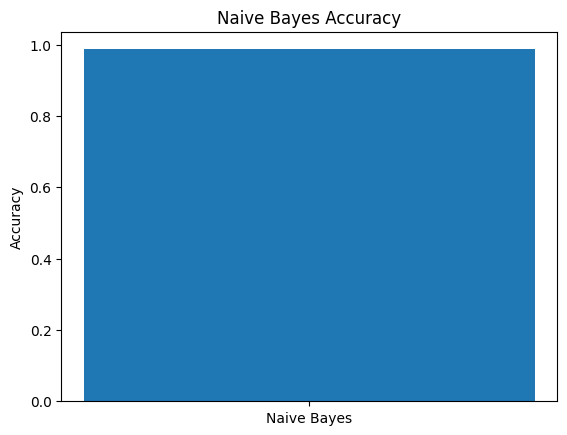

In [19]:
import matplotlib.pyplot as plt

# simple bar graph
models = ["Naive Bayes"]
accuracy = [accuracy_score(y_test, y_pred)]

plt.figure()
plt.bar(models, accuracy)

plt.title("Naive Bayes Accuracy")
plt.ylabel("Accuracy")

plt.show()

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.9866666666666667
Precision: 1.0
Recall: 0.85
F1 Score: 0.918918918918919
